In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('../data/diabetic_data.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [3]:
# statistic summary
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [4]:
# check missing values
df.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [5]:
# check duplicates
df.duplicated().sum()

0

In [6]:
 df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

In [7]:
# Create binary readmission
df['readmitted_binary'] = df['readmitted'].replace({
    'NO': 'No',
    '<30': 'Yes',
    '>30': 'Yes'
})
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,readmitted_binary
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,NO,No
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,Yes
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,No
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,No
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,No


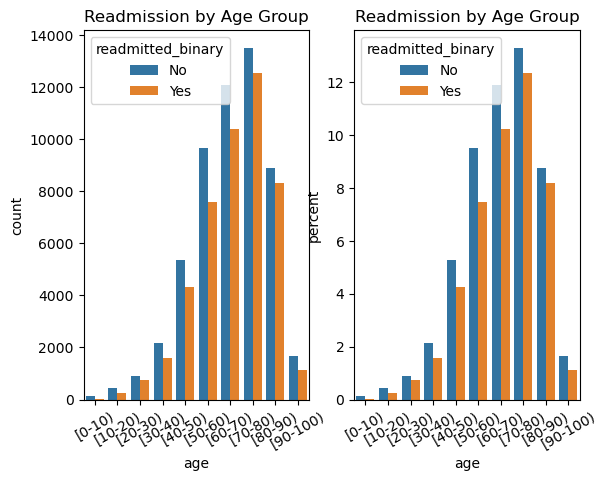

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.subplot(1,2,1)
sns.countplot(x='age', hue='readmitted_binary', data = df)
plt.title('Readmission by Age Group')
plt.xticks(rotation = 30)

plt.subplot(1,2,2)
sns.countplot(x='age', hue='readmitted_binary', data = df, stat='percent')
plt.title('Readmission by Age Group')
plt.xticks(rotation = 30)
plt.show()

In [10]:
##### SQL ######
import sqlite3

# Create dataset
conn1 = sqlite3.connect('diabetes_risk.db')

# Export pandas dataframe into SQL table
import pandas as pd
df.to_sql('diabetes_risk', conn1, if_exists='replace', index=False)

101766

In [11]:
# SQL Readmission rate by age group
query1 = '''
SELECT age,
       COUNT(*) AS total_patients,
       SUM(CASE WHEN readmitted_binary='Yes' THEN 1 ELSE 0 END) AS readmitted_patients
  FROM diabetes_risk
  GROUP BY age
'''
result1 = pd.read_sql(query1, conn1)
result1


,age,total_patients,readmitted_patients
0,[0-10),161,29
1,[10-20),691,264
2,[20-30),1657,746
3,[30-40),3775,1611
4,[40-50),9685,4305
5,[50-60),17256,7585
6,[60-70),22483,10399
7,[70-80),26068,12544
8,[80-90),17197,8301
9,[90-100),2793,1118


<function matplotlib.pyplot.show(close=None, block=None)>

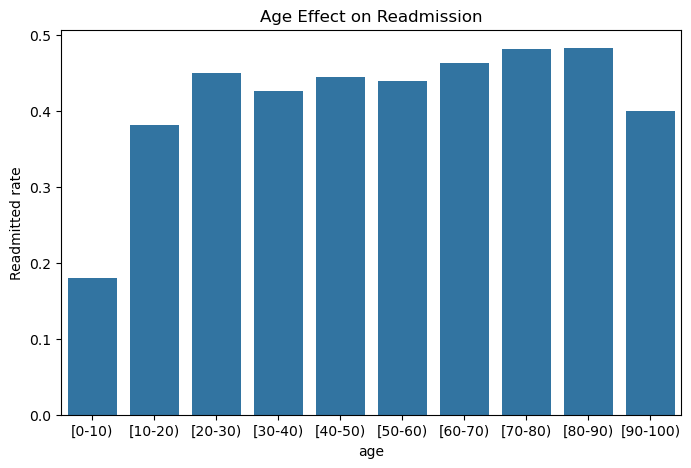

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

result1['Readmitted rate'] = result1['readmitted_patients']/result1['total_patients']
plt.figure(figsize=(8,5))
sns.barplot(
    x = 'age',
    y = 'Readmitted rate',
    data = result1
)
plt.title('Age Effect on Readmission')
plt.show

In [13]:
# SQL Average hospital stay by diagnosis
query2 = '''
SELECT diabetesMed,
       AVG(time_in_hospital) AS avg_hospital_stay
  FROM diabetes_risk
  GROUP BY diabetesMed
'''
result2 = pd.read_sql(query2, conn1)
result2

,diabetesMed,avg_hospital_stay
0,No,4.054480
1,Yes,4.497977


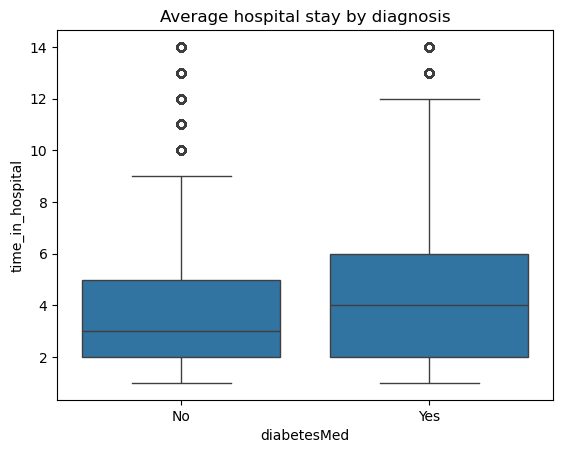

In [14]:
sns.boxplot(x='diabetesMed', y='time_in_hospital', data=df)
plt.title("Average hospital stay by diagnosis")
plt.show()

# -> diaebetes medication affects longer stay in hospital, but not significant

In [15]:
# Medication usage among high-risk patients
query3 = '''
SELECT readmitted,
       AVG(num_medications) AS avg_num_medications,
       COUNT(*) AS num_patients,
       MIN(num_medications) AS min_num_medications,
       MAX(num_medications) AS max_num_medications
  FROM diabetes_risk
  GROUP BY readmitted
'''
result3 = pd.read_sql(query3, conn1)
result3

,readmitted,avg_num_medications,num_patients,min_num_medications,max_num_medications
0,<30,16.903143,11357,1,81
1,>30,16.282768,35545,1,70
2,NO,15.670367,54864,1,79


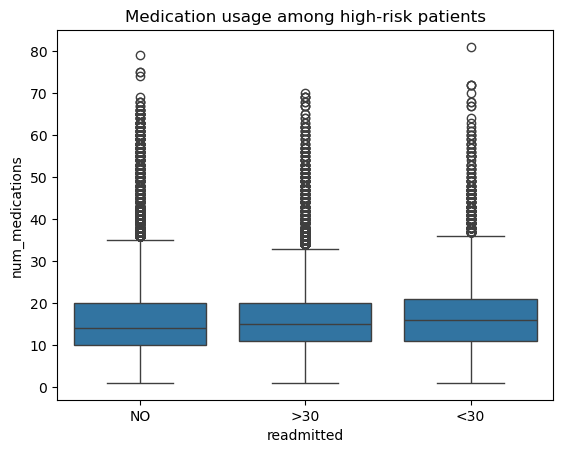

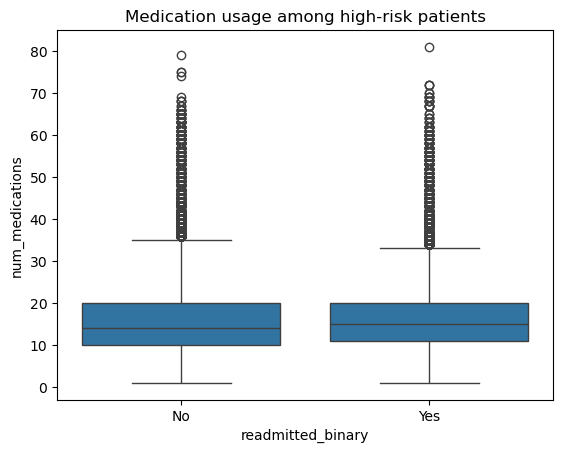

In [16]:
sns.boxplot(y='num_medications', x='readmitted', data=df)
plt.title('Medication usage among high-risk patients')
plt.show()

sns.boxplot(y='num_medications', x='readmitted_binary', data=df)
plt.title('Medication usage among high-risk patients')
plt.show()